# Prototype

## Channel Model – Key Relations

$th(x) = gpc \left( 1 - \exp(-c Q(x) t_p) \right)$  

$Q(x) = Q_0 \exp(-x/x_s)$  

$x_s \propto \sqrt{T/p_A}$

In [7]:
import torch
import torch.nn as nn

from torchdiffeq import odeint
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Channel Profile

In [8]:
N0 = 6.22*10**23
k = 1.38*10**-23 # Boltzmann constant
R = 8.314 # J/K.mol

In [9]:
class channelModel():

    def __init__(self):

        self.M = 101.96/1000 # kg/mol (molar mass of formula unit of film)
        self.rho = 3.99*1000 #density of film material

        self.b_film = 2 # number of metal atoms in the formula unit for the film
        self.b_a = 1 # number of metal atoms in the reactant, i.e. TMA
        self.c = 0.01 # c = sticking probability
        #self.Pd = 0 # Pd = Desorption probability
        self.da = 591e-12 #tma #d_estimate()
        self.db = 418e-12 #water #d_estimate()
        # Molar Mass
        self.MA = 72.09e-3 #kg/mol
        self.MB = 18e-3

        # Channel Geometry
        self.H = 0.2e-6
        self.W = 0.1e-3

        self.gpc = 106 * 10**-12 # gpc (m)
        self.K = 100 # equilibrium constant for langmuir model
        # or K = cQ/(qP_d)
        # But they seem to generally give K as its own value
        # c is used for calculating the delimiter instead

        self.T = 300 + 273 # Temperature
        self.t_p = 0.1 #pulse time

        self.pA = 100 #*1e-3 # Partial Pressure of reactant A (limiting diffusion)
        #self.pA0 = self.pA
        self.pB = 300 # partial pressure of reactant B

    def calc_hydro_diameter(self):
        self.h = 2/(1/self.H + 1/self.W)
    def calc_adsorption_density(self):
        self.q = (self.b_film/self.b_a) * (self.rho*self.gpc/self.M) * N0 #TMA q (adsorption density)
    def collision_rate(self):
        self.Q = N0/np.sqrt(2*np.pi* self.M * R * self.T)# Q: collision rate at unit pressure

    def calc_za(self):
        #find collision rate of a; (A+B) collisions and A+A collisions
        #molecular diameter, molar mass, partial pressure
        self.za = (np.pi/4*((self.da+self.db)**2)*np.sqrt(8*R*self.T/np.pi*(1/self.MA + 1/self.MB)) * self.pB + \
                   np.pi * self.da**2 * np.sqrt(16*R*self.T/(np.pi*self.MA))*self.pA) /(R*self.T)
    def calc_Deff(self):
        z_a = self.za #(self.da, self.db, self.MA, self.MB, self.pA, self.pB)
        va = np.sqrt(8*R*self.T/(np.pi * self.MA))
        Da = 3*np.pi/16 * va**2/z_a
        Dkn = self.h*np.sqrt(8*R*self.T/(9*np.pi*self.MA))
        self.Deff = 1/(1/Da + 1/Dkn)

    def approx(self, x, last_theta):

        D = self.pA*self.Deff*self.H/(self.q*k*self.T*(1-np.log(self.K*self.pA+1)/(self.K*self.pA)))
        xs = np.sqrt(D*self.t_p)
        delim = np.sqrt((self.h*N0*self.Deff)/(4*R*self.T*self.c*self.Q))
        xt = xs-delim #np.max(0.0, xs-delim)
        if xt < 0:
            xt = 0
        pt = self.pA * (1-xt/xs)
        pA = self.pA * (1-x/xs)
        pA[x>xt] = pt*np.exp(-(x[x>xt]-xt)/(xs-xt))

        theta = (self.K*pA)/(1+self.K*pA)

        next_theta = last_theta + theta

        thickness = self.gpc*next_theta

        #print('xt: ', xt)

        return thickness, next_theta, {'theta':theta, 'pA': pA}

    def run(self, steps, initial_x):

        results = []#pd.DataFrame()

        #Assuming no temperature change, these don't need recalculation
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        last_theta = initial_x.copy()

        original_H = self.H

        for step in range(steps):
            self.calc_hydro_diameter()
            self.calc_Deff()
            thickness, last_theta, intermediates = self.approx(x, last_theta)
            results.append(pd.DataFrame({'thickness': thickness} | intermediates))
            self.H = self.H - 2 * self.gpc

        self.H = original_H

        results = pd.concat(results, keys=range(steps))
        return results




In [10]:
model = channelModel()
#model.pA *= 2
model.t_p*=10
model.H = 0.5* 0.2e-6
model.W = 1000*0.2e-6

model.pA = max(model.pA, 1e-3)
model.K = max(model.K, 1e-6)

In [11]:
import numpy as np
import pandas as pd

# ===== 설정 =====
N = 200                 # step 수
gpc_nominal = 1.2e-10  # 기존 constant 값
noise_level = 0.2      # 10% noise (0.1 = 10%)

# ===== noise 생성 =====
# multiplicative noise (추천)
noise = 1 + noise_level * np.random.randn(N)

gpc_values = gpc_nominal * noise

# 음수 방지
gpc_values = np.clip(gpc_values, 0, None)

# ===== dataframe =====
df = pd.DataFrame({
    "step": np.arange(N),
    "gpc": gpc_values
})

# ===== 저장 =====
df.to_csv("gpc_data.csv", index=False)

print("gpc_data.csv 생성 완료")
df.head() 

gpc_data.csv 생성 완료


,step,gpc
0,0,1.061816e-10
1,1,1.570112e-10
2,2,1.065845e-10
3,3,1.282278e-10
4,4,1.038172e-10


In [12]:
import pandas as pd

gpc_df = pd.read_csv("gpc_data.csv")

def get_gpc(k):
    if k < len(gpc_df):
        return gpc_df.iloc[k]["gpc"]
    else:
        return gpc_df.iloc[-1]["gpc"]

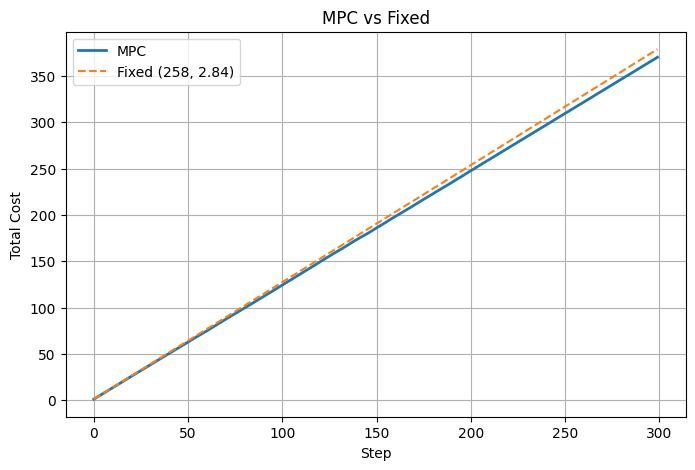


=== TOTAL COST ===
MPC   : 370.18655693829095
FIXED : 378.85055999999946


In [13]:
# ============================================================
# 0. import
# ============================================================

import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# ============================================================
# 1. gpc
# ============================================================

def get_gpc(k, path="gpc_data.csv"):
    gpc_df = pd.read_csv(path)
    if k < len(gpc_df):
        return float(gpc_df.iloc[k]["gpc"])
    return float(gpc_df.iloc[-1]["gpc"])


# ============================================================
# 2. cost function (objective = cost)
# ============================================================

def cost_function(pA_val, tp_val, pA_prev, tp_max, w_t, w_P):
    tp_n = tp_val / tp_max
    dP_n = (pA_val - pA_prev) / 50.0

    return (
        1 * tp_n/2.5
        + 0 * w_P * (dP_n**2)
        + 1 * tp_n * pA_val/(250*2.5)
        + 1 * pA_val/250
    )


# ============================================================
# 3. model
# ============================================================

class channelModelMPC(channelModel):

    def approx(self, x, last_theta):
        D = (self.pA * self.Deff * self.H /
             (self.q * k * self.T *
              (1 - np.log(self.K * self.pA + 1) / (self.K * self.pA))))
        xs = np.sqrt(D * self.t_p)

        pA_profile = self.pA * (1 - x / xs)
        pA_profile = np.clip(pA_profile, 0, None)

        theta = (self.K * pA_profile) / (1 + self.K * pA_profile)
        next_theta = last_theta + theta
        thickness = self.gpc * next_theta

        return thickness, next_theta, {'pA': pA_profile}

    def prepare(self):
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        self.calc_hydro_diameter()
        self.calc_Deff()


# ============================================================
# 4. x_half
# ============================================================

def find_x_half_pA(pA_profile, x):
    pA_half = 0.5 * pA_profile[0]
    idx = np.where(pA_profile <= pA_half)[0]

    if len(idx) == 0:
        return x[-1]

    i = idx[0]
    if i == 0:
        return x[0]

    slope = (pA_profile[i] - pA_profile[i-1]) / (x[i] - x[i-1])
    return x[i-1] + (pA_half - pA_profile[i-1]) / slope


# ============================================================
# 5. evaluate
# ============================================================

def evaluate_step(pA_val, tp_val, model, x, last_theta):
    m = copy.copy(model)
    m.pA = max(pA_val, 1e-3)
    m.t_p = tp_val
    m.prepare()

    thickness, next_theta, info = m.approx(x, last_theta)
    x_half = find_x_half_pA(info['pA'], x)

    return thickness, next_theta, x_half


# ============================================================
# 6. MPC step
# ============================================================

def mpc_step(model, x, last_theta, l_0, pA_bounds, tp_bounds):

    pA_prev = model.pA
    tp_max = tp_bounds[1]

    def objective(u):
        return cost_function(u[0], u[1], pA_prev, tp_max, w_t, w_P)

    def constraint(u):
        _, _, x_half = evaluate_step(u[0], u[1], model, x, np.zeros_like(x))
        return x_half - l_0

    result = minimize(
        objective,
        [model.pA, model.t_p],
        bounds=[pA_bounds, tp_bounds],
        constraints={'type': 'ineq', 'fun': constraint},
        method='SLSQP'
    )

    return result.x


# ============================================================
# 7. MPC run
# ============================================================

def run_mpc(x, steps, l_0, T_fixed, pA_bounds, tp_bounds):

    model = channelModelMPC()
    model.T = T_fixed
    model.pA = np.mean(pA_bounds)
    model.t_p = np.mean(tp_bounds)

    last_theta = np.zeros_like(x)
    history = []
    total_cost = 0.0

    for k in range(steps):

        model.gpc = get_gpc(k)

        pA_opt, tp_opt = mpc_step(
            model, x, last_theta, l_0, pA_bounds, tp_bounds
        )

        _, last_theta, x_half = evaluate_step(
            pA_opt, tp_opt, model, x, last_theta
        )

        pA_prev = model.pA

        cost = cost_function(
            pA_opt, tp_opt, pA_prev, tp_bounds[1], w_t, w_P
        )

        total_cost += cost

        history.append({
            'step': k,
            'cost': cost,
            'total_cost': total_cost
        })

        model.pA = pA_opt
        model.t_p = tp_opt

    return pd.DataFrame(history)


# ============================================================
# 8. FIXED run
# ============================================================

def run_fixed(x, steps, l_0, T_fixed, pA_fixed, tp_fixed, tp_bounds):

    model = channelModelMPC()
    model.T = T_fixed
    model.pA = pA_fixed
    model.t_p = tp_fixed

    last_theta = np.zeros_like(x)
    history = []
    total_cost = 0.0

    for k in range(steps):

        model.gpc = get_gpc(k)

        _, last_theta, x_half = evaluate_step(
            pA_fixed, tp_fixed, model, x, last_theta
        )

        cost = cost_function(
            pA_fixed, tp_fixed, pA_fixed, tp_bounds[1], w_t, w_P
        )

        total_cost += cost

        history.append({
            'step': k,
            'cost': cost,
            'total_cost': total_cost
        })

    return pd.DataFrame(history)


# ============================================================
# 9. 실행
# ============================================================

x = np.linspace(0, 1e-3, 500)
l_0 = 0.2e-3
T_fixed = 673

pA_bounds = (250, 500)
tp_bounds = (0.01, 10)

w_t = 1.0
w_P = 1.0

# MPC
mpc_df = run_mpc(x, 300, l_0, T_fixed, pA_bounds, tp_bounds)

# FIXED (원하는 값)
fixed_df = run_fixed(x, 300, l_0, T_fixed, 258, 2.84, tp_bounds)


# ============================================================
# 10. 비교 그래프
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(mpc_df['step'], mpc_df['total_cost'], label='MPC', linewidth=2)
plt.plot(fixed_df['step'], fixed_df['total_cost'],
         label='Fixed (258, 2.84)', linestyle='--')

plt.xlabel("Step")
plt.ylabel("Total Cost")
plt.title("MPC vs Fixed")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 11. 결과
# ============================================================

print("\n=== TOTAL COST ===")
print("MPC   :", mpc_df['total_cost'].iloc[-1])
print("FIXED :", fixed_df['total_cost'].iloc[-1])

[Feasibility] pA=500.0Pa, t_p=10.0s -> x_half=0.5222mm  (l_0=0.200mm)
  ✓ Feasible


/home/ftk3187/miniconda3/envs/dpc/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Step   0 | gpc=1.062e-10 | pA=250.00Pa | t_p=2.5958s | cost=6.5096 | total_cost=6.5096 | x_half=0.2000mm | ✓
Step   1 | gpc=1.570e-10 | pA=294.94Pa | t_p=3.2537s | cost=1.1332 | total_cost=7.6427 | x_half=0.2000mm | ✓
Step   2 | gpc=1.066e-10 | pA=250.00Pa | t_p=2.6056s | cost=1.0684 | total_cost=8.7111 | x_half=0.2000mm | ✓
Step   3 | gpc=1.282e-10 | pA=266.72Pa | t_p=2.9382s | cost=0.4057 | total_cost=9.1168 | x_half=0.2000mm | ✓
Step   4 | gpc=1.038e-10 | pA=250.00Pa | t_p=2.5380s | cost=0.3657 | total_cost=9.4824 | x_half=0.2000mm | ✓
Step   5 | gpc=1.325e-10 | pA=271.09Pa | t_p=2.9874s | cost=0.4767 | total_cost=9.9591 | x_half=0.2000mm | ✓
Step   6 | gpc=1.059e-10 | pA=250.00Pa | t_p=2.5893s | cost=0.4369 | total_cost=10.3960 | x_half=0.2000mm | ✓
Step   7 | gpc=1.181e-10 | pA=256.01Pa | t_p=2.8190s | cost=0.2963 | total_cost=10.6924 | x_half=0.2000mm | ✓
Step   8 | gpc=1.790e-10 | pA=314.67Pa | t_p=3.4770s | cost=1.7242 | total_cost=12.4166 | x_half=0.2000mm | ✓
Step   9 | gpc=1

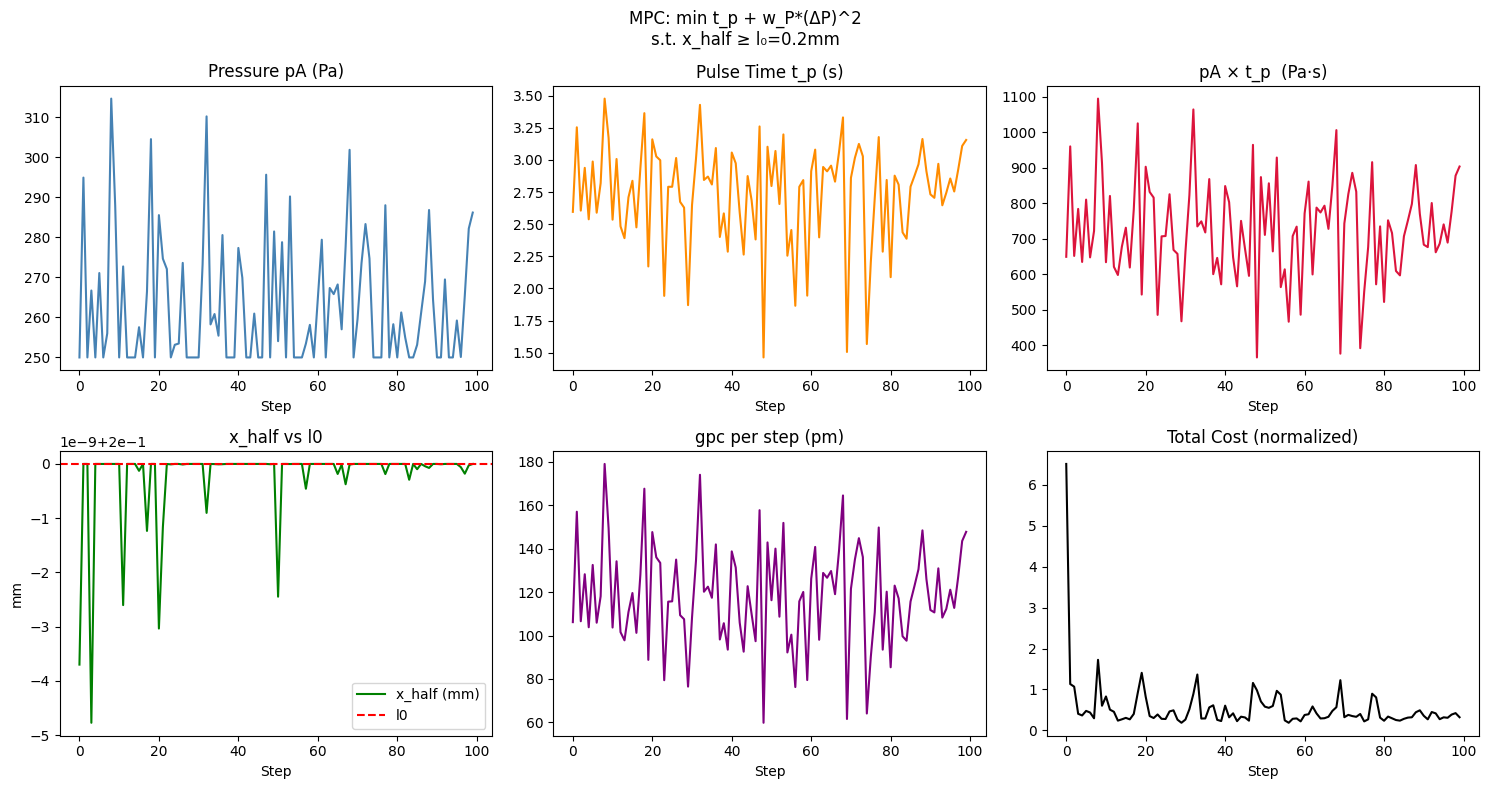

/tmp/ipykernel_2721745/3150681334.py:408: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2721745/3150681334.py:408: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2721745/3150681334.py:408: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2721745/3150681334.py:408: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2721745/3150681334.py:408: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2721745/3150681334.py:408: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2721745/3150681334.py:408: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font

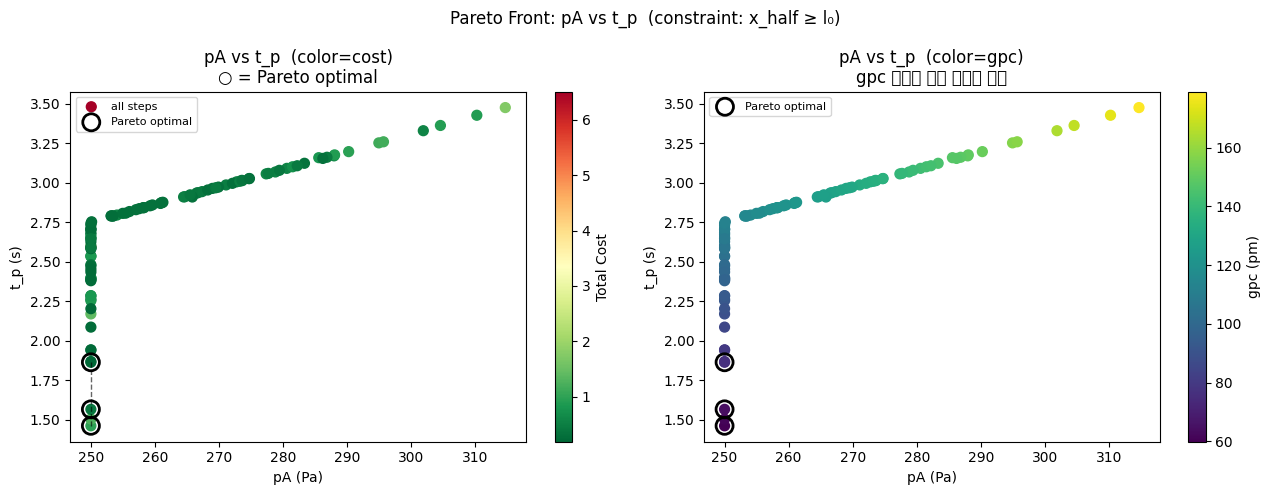


=== Summary ===
    step           gpc          pA       t_p        pA_tp      cost  total_cost  x_half  constraint_ok
0      0  1.061816e-10  250.000000  2.595761   648.940269  6.509576    6.509576  0.0002           True
1      1  1.570112e-10  294.938552  3.253711   959.644785  1.133160    7.642737  0.0002           True
2      2  1.065845e-10  250.000000  2.605612   651.403005  1.068351    8.711087  0.0002           True
3      3  1.282278e-10  266.723309  2.938235   783.695841  0.405691    9.116778  0.0002           True
4      4  1.038172e-10  250.000000  2.537961   634.490306  0.365664    9.482442  0.0002           True
5      5  1.325101e-10  271.092137  2.987446   809.873178  0.476696    9.959138  0.0002           True
6      6  1.059179e-10  250.000000  2.589314   647.328528  0.436883   10.396021  0.0002           True
7      7  1.180844e-10  256.008702  2.819012   721.691663  0.296343   10.692364  0.0002           True
8      8  1.790104e-10  314.671768  3.477034  1094.12457

In [14]:
# ============================================================
# Cell 1: 유틸리티 + 모델 확장
# ============================================================

import numpy as np
import pandas as pd
import copy
from scipy.optimize import minimize

# ----- gpc CSV reader -----
def get_gpc(k, path="gpc_data.csv"):
    gpc_df = pd.read_csv(path)
    if k < len(gpc_df):
        return float(gpc_df.iloc[k]["gpc"])
    return float(gpc_df.iloc[-1]["gpc"])


# ----- channelModel 확장 -----
class channelModelMPC(channelModel):

    def approx(self, x, last_theta):
        D = (self.pA * self.Deff * self.H /
             (self.q * k * self.T *
              (1 - np.log(self.K * self.pA + 1) / (self.K * self.pA))))
        xs    = np.sqrt(D * self.t_p)
        delim = np.sqrt((self.h * N0 * self.Deff) /
                        (4 * R * self.T * self.c * self.Q))
        xt = max(xs - delim, 0.0)

        pt = self.pA * (1 - xt / xs) if xs > 0 else 0.0
        pA_profile = self.pA * (1 - x / xs)
        if xs - xt > 0:
            pA_profile[x > xt] = pt * np.exp(-(x[x > xt] - xt) / (xs - xt))
        else:
            pA_profile[x > xt] = 0.0
        pA_profile = np.clip(pA_profile, 0, None)

        theta      = (self.K * pA_profile) / (1 + self.K * pA_profile)
        next_theta = last_theta + theta
        thickness  = self.gpc * next_theta

        return thickness, next_theta, {
            'pA'   : pA_profile,
            'theta': theta,
            'xs'   : xs,
            'xt'   : xt,
            'delim': delim,
        }

    def prepare(self):
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        self.calc_hydro_diameter()
        self.calc_Deff()


# ============================================================
# Cell 2: x_half 계산 (pA profile 기준)
# ============================================================

def find_x_half_pA(pA_profile, x):
    """
    pA(x) 가 입구값의 50% 가 되는 채널 위치.
    K=100 → theta≈1 → thickness flat → pA profile 이 유일한 공간 지표.
    """
    pA_inlet = pA_profile[0]
    if pA_inlet <= 0:
        return 0.0
    pA_half = 0.5 * pA_inlet
    idx = np.where(pA_profile <= pA_half)[0]
    if len(idx) == 0:
        return x[-1]
    i = idx[0]
    if i == 0:
        return x[0]
    slope = (pA_profile[i] - pA_profile[i-1]) / (x[i] - x[i-1])
    return float(x[i-1] + (pA_half - pA_profile[i-1]) / slope)


# ============================================================
# Cell 3: 단일 스텝 평가
# ============================================================

def evaluate_step(pA_val, tp_val, model, x, last_theta):
    m = copy.copy(model)          # model 상태 보호 (optimizer iteration 간 오염 방지)
    m.pA  = max(pA_val, 1e-3)
    m.t_p = tp_val
    m.prepare()
    thickness, next_theta, info = m.approx(x, last_theta)
    x_half = find_x_half_pA(info['pA'], x)
    return thickness, next_theta, x_half, info


# ============================================================
# Cell 4: MPC 1-step optimizer
# ============================================================

def mpc_step(model, x, last_theta, l_0,
             pA_bounds, tp_bounds, w_t, w_P):

    pA_max = pA_bounds[1]
    pA_min = pA_bounds[0]
    tp_max = tp_bounds[1]

    pA_prev = model.pA   # ⭐ 핵심

    def objective(u):
        pA_val, tp_val = u

        tp_n = tp_val / tp_max
        #dP_scale = 50.0
        #dP_n = (pA_val - pA_prev) / dP_scale

        return w_t * tp_n +  1 * tp_n * pA_val + 0.001 * pA_val

    _zeros = np.zeros_like(x)

    def con_x_half(u):
        pA_val, tp_val = u
        _, _, x_half, _ = evaluate_step(pA_val, tp_val, model, x, _zeros)
        return x_half - l_0
    
    # ---- coarse global search for robust initialization ----
    P_grid = np.linspace(pA_bounds[0], pA_bounds[1], 80)
    t_grid = np.linspace(tp_bounds[0], tp_bounds[1], 80)

    best_u = None
    best_J = np.inf

    for P in P_grid:
        for tp in t_grid:
            _, _, xh, _ = evaluate_step(P, tp, model, x, _zeros)
            if xh >= l_0:
                tp_n = tp / tp_max
                dP_scale = 50.0
                dP_n = (P - pA_prev) / dP_scale
                J = w_t * tp_n + w_P * dP_n**2
                if J < best_J:
                    best_J = J
                    best_u = [P, tp]

    if best_u is None:
        print("[WARN] No feasible point found in grid.")
        u0 = [model.pA, model.t_p]
    else:
        u0 = best_u
    bounds = [pA_bounds, tp_bounds]
    constr = {'type': 'ineq', 'fun': con_x_half}

    result = minimize(
        objective, u0,
        method='SLSQP',
        bounds=bounds,
        constraints=constr,
        options={'ftol': 1e-10, 'maxiter': 500}
    )

    if not result.success:
        print(f"  [WARN] {result.message}")

    return result.x[0], result.x[1], result


# ============================================================
# Cell 5: MPC 루프
# ============================================================

def run_mpc(x, steps, l_0,
            T_fixed, pA_bounds, tp_bounds, alpha, beta,
            gpc_csv = "gpc_data.csv"):
    
    mpc_model     = channelModelMPC()
    mpc_model.T   = T_fixed
    mpc_model.pA  = np.mean(pA_bounds)
    mpc_model.t_p = np.mean(tp_bounds)

    last_theta = np.zeros_like(x)
    history    = []

    # ✅ 누적 cost 변수 추가
    total_cost = 0.0

    for k in range(steps):

        # ── 1. gpc 업데이트 ──
        mpc_model.gpc = get_gpc(k, gpc_csv)

        # ── 2. 최적 (pA, t_p) 계산 ──
        pA_opt, tp_opt, result = mpc_step(
            mpc_model, x, last_theta, l_0,
            pA_bounds=pA_bounds,
            tp_bounds=tp_bounds,
            w_t=w_t,
            w_P=w_P,
        )

        # ── 3. 적용 → 다음 상태 ──
        thickness, last_theta, x_half, info = evaluate_step(
            pA_opt, tp_opt, mpc_model, x, last_theta
        )

        pA_max_val = pA_bounds[1]
        tp_max_val = tp_bounds[1]

        # 이전 pressure
        pA_prev = mpc_model.pA

        # normalization
        tp_n = tp_opt / tp_max_val

        dP_scale = 50.0
        dP_n = (pA_opt - pA_prev) / dP_scale

        # step cost
        cost = w_t * tp_n + w_P * (dP_n**2)

        # ✅ 누적 cost 업데이트
        total_cost += cost

        ok = x_half >= l_0 - 1e-9

        history.append({
            'step'          : k,
            'gpc'           : mpc_model.gpc,
            'pA'            : pA_opt,
            't_p'           : tp_opt,
            'cost'          : cost,
            'total_cost'    : total_cost,   # ✅ 추가
            'pA_tp'         : pA_opt * tp_opt,
            'x_half'        : x_half,
            'l_0'           : l_0,
            'constraint_ok' : ok,
            'xs'            : info['xs'],
            'thickness_in'  : thickness[0],
            'thickness_tip' : thickness[-1],
        })

        # warm-start
        mpc_model.pA  = pA_opt
        mpc_model.t_p = tp_opt

        # ✅ print에 total cost 추가
        print(f"Step {k:3d} | gpc={mpc_model.gpc:.3e} | "
              f"pA={pA_opt:.2f}Pa | t_p={tp_opt:.4f}s | "
              f"cost={cost:.4f} | total_cost={total_cost:.4f} | "
              f"x_half={x_half*1e3:.4f}mm | "
              f"{'✓' if ok else '✗ VIOLATION'}")

    return pd.DataFrame(history)


# ============================================================
# Cell 6: 실행 & 시각화
# ============================================================

x         = np.linspace(0, 1e-3, 500)
l_0       = 0.2e-3
T_fixed   = 400 + 273
pA_bounds = (250.0, 500.0)
tp_bounds = (0.01, 10.0)

# alpha, beta 설정
# alpha=1, beta=1 : pA 와 t_p 동등 페널티  → 균형잡힌 tradeoff
# alpha>beta      : pA 낮추는 방향 선호    → 가스 절약 우선
# beta>alpha      : t_p 낮추는 방향 선호   → throughput 우선
alpha = 0.0   # pA 페널티 약간 높게: pA 낮추되 t_p bound 에 안 붙는 수준
beta  = 0.0
w_t = 1.0
w_P = 1.0   

# ── feasibility 사전 확인 ──
_check     = channelModelMPC()
_check.T   = T_fixed
_check.gpc = 1.2e-10
_, _, xh_max, _ = evaluate_step(
    pA_bounds[1], tp_bounds[1], _check, x, np.zeros_like(x)
)
print(f"[Feasibility] pA={pA_bounds[1]}Pa, t_p={tp_bounds[1]}s "
      f"-> x_half={xh_max*1e3:.4f}mm  (l_0={l_0*1e3:.3f}mm)")
print("  ✓ Feasible" if xh_max >= l_0 else
      f"  ⚠ INFEASIBLE: l_0을 {xh_max*1e3:.4f}mm 이하로 낮추거나 bounds를 넓히세요.")

# ── MPC 실행 ──
history_df = run_mpc(
    x         = x,
    steps     = 100,
    l_0       = l_0,
    T_fixed   = T_fixed,
    pA_bounds = pA_bounds,
    tp_bounds = tp_bounds,
    alpha     = alpha,
    beta      = beta,
    gpc_csv   = "gpc_data.csv",
    
)
history_df['total_cost'] = history_df['cost'].cumsum()


# ── cost 컬럼 추가 ──
pA_max_val = pA_bounds[1]
tp_max_val = tp_bounds[1]
# history_df['cost'] = (
#     (history_df['pA'] / pA_max_val) * (history_df['t_p'] / tp_max_val)
#     + alpha * (history_df['pA'] / pA_max_val)
#     + beta  * (history_df['t_p'] / tp_max_val)
# )

# ── Pareto optimal 포인트 추출 (pA, t_p 두 목표) ──
def is_pareto(costs):
    n = len(costs)
    mask = np.ones(n, dtype=bool)
    for i in range(n):
        if mask[i]:
            dominated = (
                np.all(costs <= costs[i], axis=1) &
                np.any(costs <  costs[i], axis=1)
            )
            dominated[i] = False
            if dominated.any():
                mask[i] = False
    return mask

pareto_costs = history_df[['t_p', 'cost']].values
pareto_mask  = is_pareto(pareto_costs)

# ── Fig 1: 시계열 ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    f"MPC: min t_p + w_P*(ΔP)^2\n"
    f"s.t. x_half ≥ l₀={l_0*1e3:.1f}mm",
    fontsize=12
)
steps_arr = history_df['step']

axes[0,0].plot(steps_arr, history_df['pA'], color='steelblue')
axes[0,0].set_title("Pressure pA (Pa)")
axes[0,0].set_xlabel("Step")

axes[0,1].plot(steps_arr, history_df['t_p'], color='darkorange')
axes[0,1].set_title("Pulse Time t_p (s)")
axes[0,1].set_xlabel("Step")

axes[0,2].plot(steps_arr, history_df['pA_tp'], color='crimson')
axes[0,2].set_title("pA × t_p  (Pa·s)")
axes[0,2].set_xlabel("Step")

axes[1,0].plot(steps_arr, history_df['x_half']*1e3, label="x_half (mm)", color='green')
axes[1,0].axhline(l_0*1e3, linestyle='--', color='red', label="l0")
axes[1,0].set_title("x_half vs l0")
axes[1,0].set_xlabel("Step")
axes[1,0].set_ylabel("mm")
axes[1,0].legend()

axes[1,1].plot(steps_arr, history_df['gpc']*1e12, color='purple')
axes[1,1].set_title("gpc per step (pm)")
axes[1,1].set_xlabel("Step")

# 총 cost 시계열
axes[1,2].plot(steps_arr, history_df['cost'], color='black', linewidth=1.5)
axes[1,2].set_title("Total Cost (normalized)")
axes[1,2].set_xlabel("Step")

plt.tight_layout()
plt.savefig("mpc_result.png", dpi=150)
plt.show()

# ── Fig 2: Pareto Front ──
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("Pareto Front: pA vs t_p  (constraint: x_half ≥ l₀)", fontsize=12)

# 왼쪽: color = total cost
sc = axes2[0].scatter(
    history_df['pA'], history_df['t_p'],
    c=history_df['cost'], cmap='RdYlGn_r', s=50, zorder=2, label='all steps'
)
plt.colorbar(sc, ax=axes2[0], label='Total Cost')
axes2[0].scatter(
    history_df.loc[pareto_mask, 'pA'],
    history_df.loc[pareto_mask, 't_p'],
    edgecolors='black', facecolors='none', s=150, linewidths=2,
    zorder=3, label='Pareto optimal'
)
pf = history_df[pareto_mask].sort_values('pA')
axes2[0].plot(pf['pA'], pf['t_p'], 'k--', linewidth=1, alpha=0.6)
axes2[0].set_xlabel("pA (Pa)")
axes2[0].set_ylabel("t_p (s)")
axes2[0].set_title("pA vs t_p  (color=cost)\n○ = Pareto optimal")
axes2[0].legend(fontsize=8)

# 오른쪽: color = gpc (gpc 변화에 따른 최적해 이동)
sc2 = axes2[1].scatter(
    history_df['pA'], history_df['t_p'],
    c=history_df['gpc']*1e12, cmap='viridis', s=50, zorder=2
)
plt.colorbar(sc2, ax=axes2[1], label='gpc (pm)')
axes2[1].scatter(
    history_df.loc[pareto_mask, 'pA'],
    history_df.loc[pareto_mask, 't_p'],
    edgecolors='black', facecolors='none', s=150, linewidths=2,
    zorder=3, label='Pareto optimal'
)
axes2[1].set_xlabel("pA (Pa)")
axes2[1].set_ylabel("t_p (s)")
axes2[1].set_title("pA vs t_p  (color=gpc)\ngpc 변화에 따른 최적해 이동")
axes2[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("mpc_pareto.png", dpi=150)
plt.show()

print("\n=== Summary ===")
print(history_df[['step','gpc','pA','t_p','pA_tp','cost','total_cost',
                   'x_half','constraint_ok']].to_string())
